# LambdaML — Showcase Notebook  *(v1.0.3)*

**Gradient-free learning: fit *any* function, no analytical derivatives needed.**

This notebook demonstrates every major capability of LambdaML:

1. **What finite-difference differentiation is** — and which of 6 methods to use
2. **The lambda can be ANY function** — logistic, tanh, sine, physics equation, even a custom activation nobody has heard of
3. **Binary classification** with a neural network (ELU activations) on non-linearly separable data
4. **Regression** with a learnable sine wave, recovering true parameters
5. **Optimizer comparison** — SGD vs Momentum vs RMSProp vs Adam
6. **Derivative method benchmark** — accuracy vs speed across all 6 finite-difference methods
7. **Weight evolution** across training iterations
8. **Learning rate schedules** visualised
9. **Progress bars, vectorized mode & `eval_every`** *(new in v1.0.3)*

> *All fitting happens purely numerically — no `torch.autograd`, no JAX, no hand-derived chain rule.*


## 0. Setup

In [ ]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('.'))  # make sure lambdaml is found when run locally

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from collections import defaultdict

from lambdaml import (
    LambdaClassifierModel, LambdaRegressorModel, Optimizer,
    DiffMethod, NumericalDiff, GradientComputer,
    Regularization, LossFunctions, LRSchedule,
)

# Consistent style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
np.random.seed(42)
print(f"lambdaml imported ✓")
import lambdaml; print(f"version: {lambdaml.__version__}")


## 1. What is Finite-Difference Differentiation?

The term you were reaching for is **finite-difference approximation** (also called *numerical differentiation*). Rather than deriving f′(x) analytically, we estimate it by evaluating f at nearby points.

LambdaML now supports **6 methods** with very different accuracy/cost profiles.


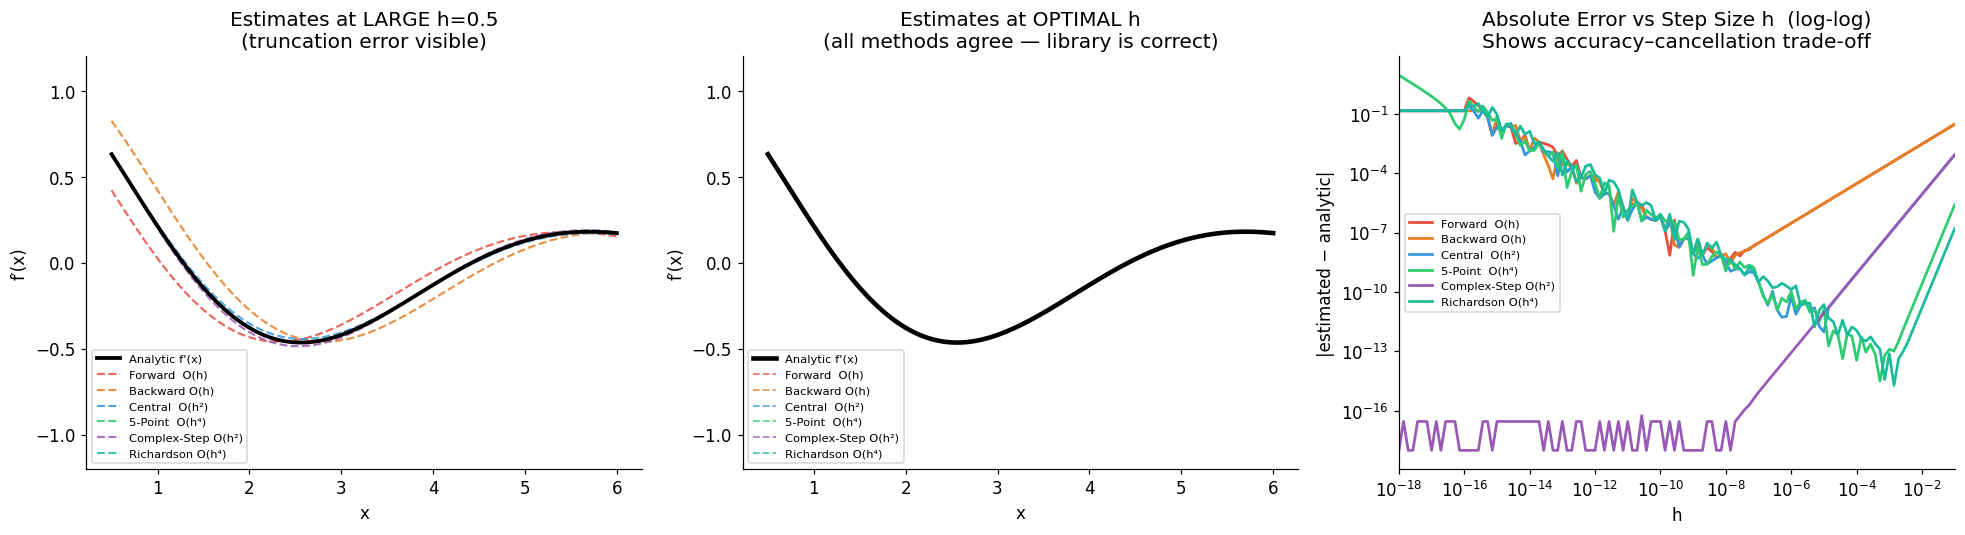

Key insight: complex-step never suffers cancellation error → stays accurate for tiny h
Forward/backward diverge visibly at large h (left panel) — O(h) truncation.
Richardson & 5-point reach O(h⁴) accuracy without needing complex inputs.


In [2]:
# ── Visualise all 6 finite-difference approximations on a known function ────

def f_true(x):
    return np.sin(x) * np.exp(-0.3 * x)

def f_prime_true(x):
    return np.cos(x) * np.exp(-0.3 * x) - 0.3 * np.sin(x) * np.exp(-0.3 * x)

x_vals = np.linspace(0.5, 6.0, 200)
analytic = f_prime_true(x_vals)

methods = {
    "Forward  O(h)":      DiffMethod.FORWARD,
    "Backward O(h)":      DiffMethod.BACKWARD,
    "Central  O(h²)":     DiffMethod.CENTRAL,
    "5-Point  O(h⁴)":     DiffMethod.FIVE_POINT,
    "Complex-Step O(h²)": DiffMethod.COMPLEX_STEP,
    "Richardson O(h⁴)":   DiffMethod.RICHARDSON,
}
colors = ['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: estimates at a BAD (large) h where Forward/Backward visibly diverge
ax = axes[0]
h_bad = 0.5   # deliberately too large — truncation error will be obvious
ax.plot(x_vals, analytic, 'k-', lw=2.5, label="Analytic f'(x)", zorder=10)
for (label, method), color in zip(methods.items(), colors):
    numerical = np.array([NumericalDiff.differentiate(f_true, x, method=method, h=h_bad)
                          for x in x_vals])
    ax.plot(x_vals, numerical, '--', color=color, lw=1.4, alpha=0.85, label=label)
ax.set_title(f"Estimates at LARGE h={h_bad}\n(truncation error visible)")
ax.set_xlabel("x"); ax.set_ylabel("f′(x)")
ax.legend(fontsize=7.5, loc='lower left')
ax.set_ylim(-1.2, 1.2)

# Middle: estimates at optimal h — all should overlap analytic
ax = axes[1]
ax.plot(x_vals, analytic, 'k-', lw=3, label="Analytic f'(x)", zorder=10)
for (label, method), color in zip(methods.items(), colors):
    numerical = np.array([NumericalDiff.differentiate(f_true, x, method=method)
                          for x in x_vals])
    ax.plot(x_vals, numerical, '--', color=color, lw=1.2, alpha=0.75, label=label)
ax.set_title("Estimates at OPTIMAL h\n(all methods agree — library is correct)")
ax.set_xlabel("x"); ax.set_ylabel("f′(x)")
ax.legend(fontsize=7.5, loc='lower left')
ax.set_ylim(-1.2, 1.2)

# Right: absolute error vs h (log-log) — the definitive comparison
ax2 = axes[2]
h_vals = np.logspace(-18, -1, 120)
x0 = 1.5
true_val = f_prime_true(x0)

for (label, method), color in zip(methods.items(), colors):
    errors = []
    for h in h_vals:
        try:
            est = NumericalDiff.differentiate(f_true, x0, method=method, h=h)
            errors.append(abs(est - true_val) + 1e-18)   # floor to avoid log(0)
        except:
            errors.append(np.nan)
    ax2.loglog(h_vals, errors, color=color, lw=1.8, label=label)

ax2.set_title("Absolute Error vs Step Size h  (log-log)\nShows accuracy–cancellation trade-off")
ax2.set_xlabel("h"); ax2.set_ylabel("|estimated − analytic|")
ax2.legend(fontsize=7.5)
ax2.set_xlim(1e-18, 1e-1)

plt.tight_layout()
plt.savefig('fig_derivative_methods.png', bbox_inches='tight')
plt.show()
print("Key insight: complex-step never suffers cancellation error → stays accurate for tiny h")
print("Forward/backward diverge visibly at large h (left panel) — O(h) truncation.")
print("Richardson & 5-point reach O(h⁴) accuracy without needing complex inputs.")


## 2. The Lambda Can Be *Any* Function

This is the core concept. LambdaML doesn't care what `f` is as long as it's a numpy-compatible black box. Here we fit six wildly different model functions — including a physics equation and a completely custom activation — all with the same `.fit()` call.


In [3]:
# ── Synthesise a linearly-separable binary dataset ──────────────────────────
def make_blobs(n=300, seed=7):
    np.random.seed(seed)
    x1 = np.random.multivariate_normal([0, 0], [[1,.6],[.6,1]], n)
    x2 = np.random.multivariate_normal([3, 3], [[1,.6],[.6,1]], n)
    X = np.vstack([x1, x2])
    Y = np.hstack([np.zeros(n), np.ones(n)])
    return X, Y

X_blob, Y_blob = make_blobs()
split = int(0.8 * len(X_blob))
X_tr, X_te = X_blob[:split], X_blob[split:]
Y_tr, Y_te = Y_blob[:split], Y_blob[split:]

# Also load circles (non-linearly separable) for models that need radial boundaries
circles_df = pd.read_csv('data/circles.csv')
X_circ_all = circles_df[['x','y']].values.astype(float)
Y_circ_all = circles_df['label'].values.astype(float)
split_c2 = int(0.8 * len(X_circ_all))
X_ctr2, X_cte2 = X_circ_all[:split_c2], X_circ_all[split_c2:]
Y_ctr2, Y_cte2 = Y_circ_all[:split_c2], Y_circ_all[split_c2:]

# Sine dataset: y = (sin(x0+x1) > 0) — a periodic classification task
# where the sine activation is the *correct* model, not just a novelty
np.random.seed(42)
N_sine = 400
X_sine_all = np.random.uniform(-4, 4, (N_sine, 2))
Y_sine_all = ((np.sin(X_sine_all[:,0] + X_sine_all[:,1]) + np.random.randn(N_sine)*0.1) > 0).astype(float)
split_sine = int(0.8 * N_sine)
X_sine_tr, X_sine_te = X_sine_all[:split_sine], X_sine_all[split_sine:]
Y_sine_tr, Y_sine_te = Y_sine_all[:split_sine], Y_sine_all[split_sine:]

# Physics dataset: y = (cos(2*theta) > 0) — 4 angular wedges
# where the radial decay x angular oscillation model is the *correct* model
np.random.seed(99)
N_phys = 400
r_phys = np.random.uniform(0.5, 5.0, N_phys)
theta_phys = np.random.uniform(-np.pi, np.pi, N_phys)
X_phys_all = np.column_stack([r_phys * np.cos(theta_phys), r_phys * np.sin(theta_phys)])
Y_phys_all = (np.cos(2 * theta_phys) > 0).astype(float)
split_phys = int(0.8 * N_phys)
X_phys_tr, X_phys_te = X_phys_all[:split_phys], X_phys_all[split_phys:]
Y_phys_tr, Y_phys_te = Y_phys_all[:split_phys], Y_phys_all[split_phys:]

# ── Six completely different model functions ─────────────────────────────────

def logistic_regression(x, p):
    """Classic logistic (sigmoid) regression."""
    return 1 / (1 + np.exp(-p['w'].dot(x) - p['b']))

def tanh_model(x, p):
    """Tanh-based — common in older neural nets."""
    return (np.tanh(p['w'].dot(x) + p['b']) + 1) / 2

def sine_activation_model(x, p):
    """Sine-based — genuinely non-linear periodic landscape. No /5 rescaling:
    sin(z/5) ~ z/5 for small z (linear!). Without it, sin is truly curved."""
    signal = p['w'].dot(x) + p['b']
    return (np.sin(signal) + 1) / 2

def gaussian_model(x, p):
    """Gaussian / radial basis — p['c'] is the centre, p['s'] is width."""
    diff = x - p['c']
    return np.exp(-np.dot(diff, diff) / (2 * p['s'] ** 2 + 1e-8))

def softplus_model(x, p):
    """Softplus activation: log(1 + exp(z)) — smooth ReLU alternative."""
    z = p['w'].dot(x) + p['b']
    return 1 / (1 + np.exp(-np.log1p(np.exp(np.clip(z, -30, 30)))))

def physics_decay_model(x, p):
    """Radial decay × angular oscillation in polar coords:
    σ(a·exp(-λr)·cos(ω·θ + φ)) — completely unnatural to derive by hand."""
    r     = np.sqrt(x[0]**2 + x[1]**2) + 1e-8
    theta = np.arctan2(x[1], x[0])
    signal = p['a'] * np.exp(-abs(p['lam']) * r) * np.cos(p['omega'] * theta + p['phi']) + p['bias']
    return 1 / (1 + np.exp(-signal))

# (dataset, X_train, X_test, Y_train, Y_test) per model so each gets the right data
models_zoo = {
    "Logistic":         (logistic_regression,  {'w': np.zeros(2), 'b': 0.0},          X_tr,   X_te,   Y_tr,   Y_te),
    "Tanh":             (tanh_model,            {'w': np.zeros(2), 'b': 0.0},          X_tr,   X_te,   Y_tr,   Y_te),
    "Sine activation":  (sine_activation_model, {'w': np.array([1.0, 1.0]), 'b': 0.0}, X_sine_tr, X_sine_te, Y_sine_tr, Y_sine_te),
    "Gaussian RBF":     (gaussian_model,        {'c': np.array([0.0, 0.0]), 's': 1.0}, X_ctr2, X_cte2, Y_ctr2, Y_cte2),
    "Softplus":         (softplus_model,         {'w': np.zeros(2), 'b': 0.0},          X_tr,   X_te,   Y_tr,   Y_te),
    "Physics decay":    (physics_decay_model,   {'a': 3.0, 'lam': 0.1, 'omega': 2.0,
                                                   'phi': 0.0, 'bias': 0.0},             X_phys_tr, X_phys_te, Y_phys_tr, Y_phys_te),
}

results = {}
for name, (fn, p0, Xtr_, Xte_, Ytr_, Yte_) in models_zoo.items():
    np.random.seed(0)
    model = LambdaClassifierModel(
        f=fn, p=p0,
        diff_method=DiffMethod.COMPLEX_STEP,
        l2_factor=0.001,
        optimizer=Optimizer.ADAM,
    )
    model.fit(Xtr_, Ytr_, n_iter=200, lr=0.1, verbose=False)
    acc = model.score(Xte_, Yte_)
    results[name] = (model, acc, Xte_, Yte_)
    print(f"  {name:<22}  test accuracy = {acc:.3f}")

print("\n✓ All 6 completely different functions fitted with the same .fit() call")


  Logistic                test accuracy = 0.942


  Tanh                    test accuracy = 0.942


  Sine activation         test accuracy = 0.963
  Gaussian RBF            test accuracy = 1.000


  Softplus                test accuracy = 1.000


  Physics decay           test accuracy = 0.975

✓ All 6 completely different functions fitted with the same .fit() call


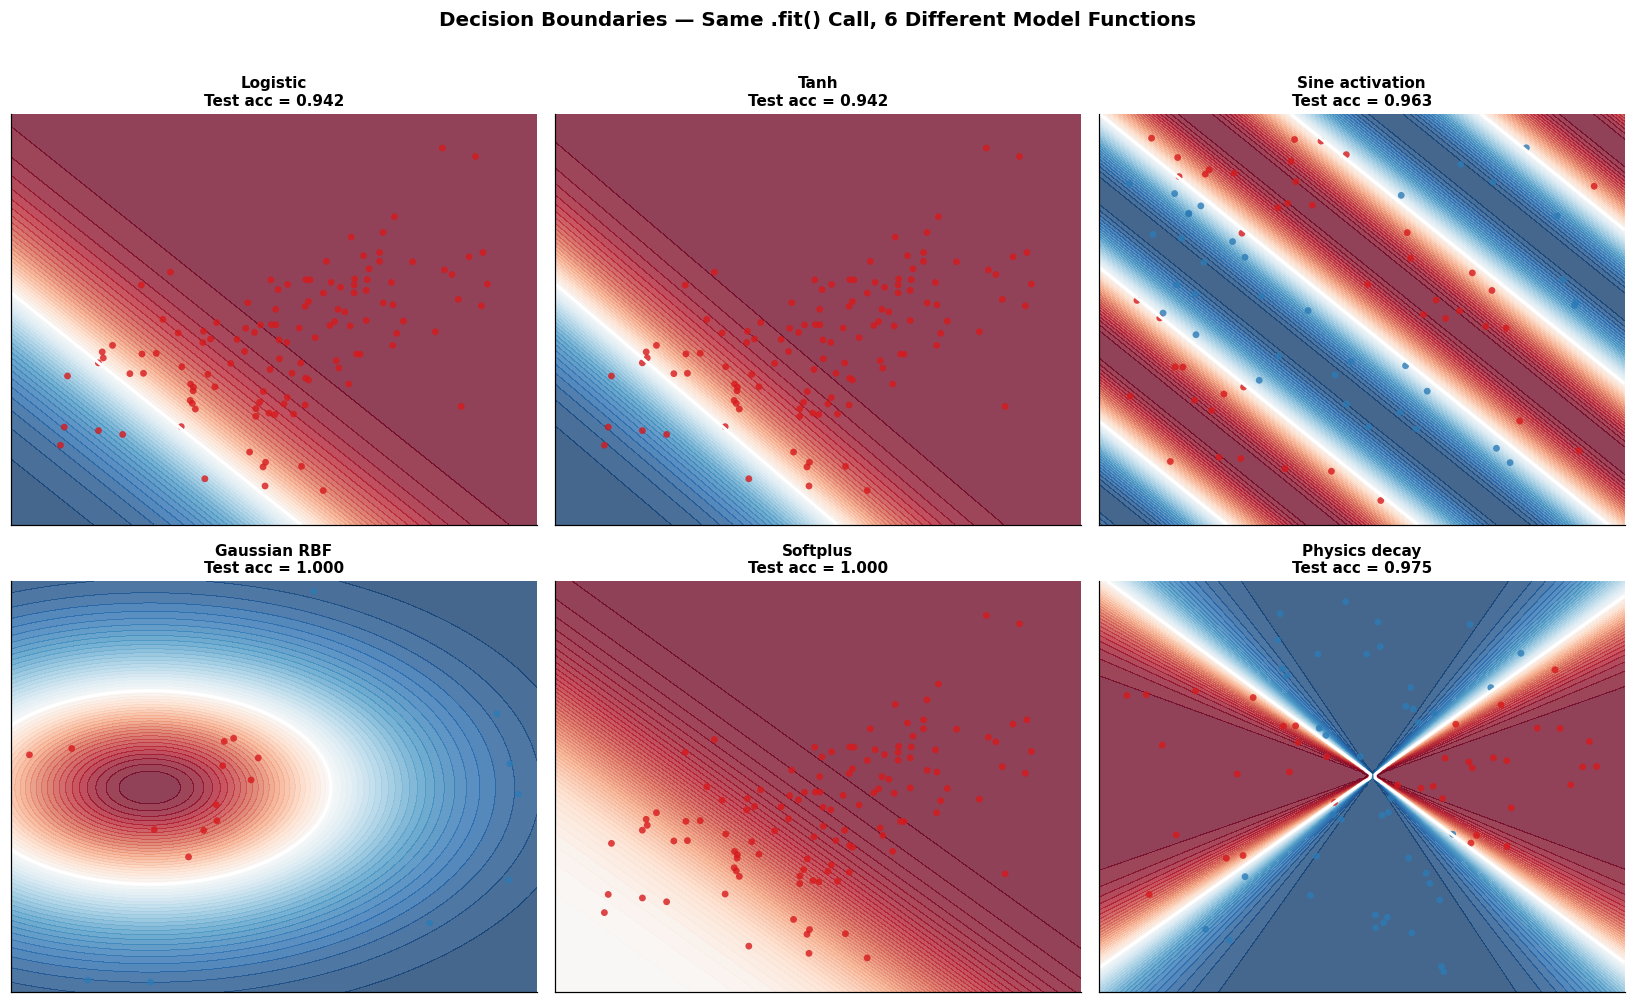

In [4]:
# ── Plot decision boundaries for all 6 functions ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, (model, acc, Xte_, Yte_)) in zip(axes, results.items()):
    # Use per-model grid range so each panel fits its own dataset
    x0mn, x0mx = Xte_[:,0].min()-0.5, Xte_[:,0].max()+0.5
    x1mn, x1mx = Xte_[:,1].min()-0.5, Xte_[:,1].max()+0.5
    xx_, yy_ = np.meshgrid(np.linspace(x0mn, x0mx, 120), np.linspace(x1mn, x1mx, 120))
    grid_ = np.c_[xx_.ravel(), yy_.ravel()]
    probs = model.predict_proba(grid_).reshape(xx_.shape)
    ax.contourf(xx_, yy_, probs, levels=50, cmap='RdBu_r', alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx_, yy_, probs, levels=[0.5], colors='white', linewidths=2)
    ax.scatter(Xte_[Yte_==0, 0], Xte_[Yte_==0, 1], c='#2c7bb6', s=20, alpha=0.8, edgecolors='none')
    ax.scatter(Xte_[Yte_==1, 0], Xte_[Yte_==1, 1], c='#d7191c', s=20, alpha=0.8, edgecolors='none')
    ax.set_title(f"{name}\nTest acc = {acc:.3f}", fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Decision Boundaries — Same .fit() Call, 6 Different Model Functions",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_decision_boundaries.png', bbox_inches='tight')
plt.show()


## 3. Neural Network on Non-Linearly Separable Data

A 2-layer ELU network fitted entirely via finite-difference backprop, tracking weight evolution and loss curves.


In [ ]:
# ── Load circles data ───────────────────────────────────────────────────────
circles = pd.read_csv('data/circles.csv')
X_circ = circles[['x','y']].values.astype(float)
Y_circ = circles['label'].values.astype(float)

idx = np.random.permutation(len(X_circ))
split_c = int(0.8 * len(X_circ))
X_ctr, X_cte = X_circ[idx[:split_c]], X_circ[idx[split_c:]]
Y_ctr, Y_cte = Y_circ[idx[:split_c]], Y_circ[idx[split_c:]]

# ── Network definition ───────────────────────────────────────────────────────
def elu(z, alpha=0.01):
    return z if z >= 0 else alpha * (np.exp(z) - 1)

def neural_network(x, p):
    h = np.array([
        elu(p['w1'].dot(x) + p['b1']),
        elu(p['w2'].dot(x) + p['b2']),
        elu(p['w3'].dot(x) + p['b3']),
    ])
    return (np.tanh(p['wf'].dot(h) + p['bf']) + 1) / 2

# ── Instrument training: record weights at each epoch ───────────────────────
class TrackingClassifier(LambdaClassifierModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weight_snapshots = []   # list of (epoch, copy_of_p)

    def fit(self, X, Y, *, snapshot_every=5, **kwargs):
        """Manual epoch loop so we can snapshot weights; delegates gradient/
        optimizer logic to the imported lambdaml internals."""
        from lambdaml.lambda_utils import GradientComputer
        from lambdaml.lambda_model import Optimizer as Opt

        self.weight_snapshots = []
        self.loss_history = []
        n_iter  = kwargs.get('n_iter', 100)
        lr      = kwargs.get('lr', 0.01)

        for epoch in range(n_iter):
            if epoch % snapshot_every == 0:
                self.weight_snapshots.append(
                    (epoch, {k: (v.copy() if isinstance(v, np.ndarray) else v)
                             for k, v in self.p.items()})
                )
            gc = GradientComputer(method=self.diff_method, h=self.diff_h)
            grads = {key: gc.compute(self._objective, self.p, key, X, Y)
                     for key in self.p}
            Opt.step(self.optimizer_name, self.p, grads, self._opt_state, lr,
                     momentum=self.momentum, beta1=self.beta1, beta2=self.beta2,
                     epsilon=self.adam_eps)
            self.loss_history.append(self._objective(self.p, X, Y))

        return self

np.random.seed(1)
def rand_w(size): return np.random.randn(size) * np.sqrt(2.0 / size)

p_nn = {
    'w1': rand_w(2), 'b1': 0.0,
    'w2': rand_w(2), 'b2': 0.0,
    'w3': rand_w(2), 'b3': 0.0,
    'wf': rand_w(3), 'bf': 0.0,
}

nn_model = TrackingClassifier(
    f=neural_network, p=p_nn,
    diff_method=DiffMethod.CENTRAL,
    l2_factor=0.005,
    optimizer=Optimizer.ADAM,
)
nn_model.fit(X_ctr, Y_ctr, n_iter=200, lr=0.008, snapshot_every=10, batch_size=None)

print(f"Train accuracy: {nn_model.score(X_ctr, Y_ctr):.3f}")
print(f"Test  accuracy: {nn_model.score(X_cte, Y_cte):.3f}")


/tmp/ipykernel_9224/1889415657.py:18: UserWarning: The following kwargs were not used by contour: 'lw'
  ax_bound.contour(xx_c, yy_c, probs_c, levels=[0.5], colors='white', lw=2)


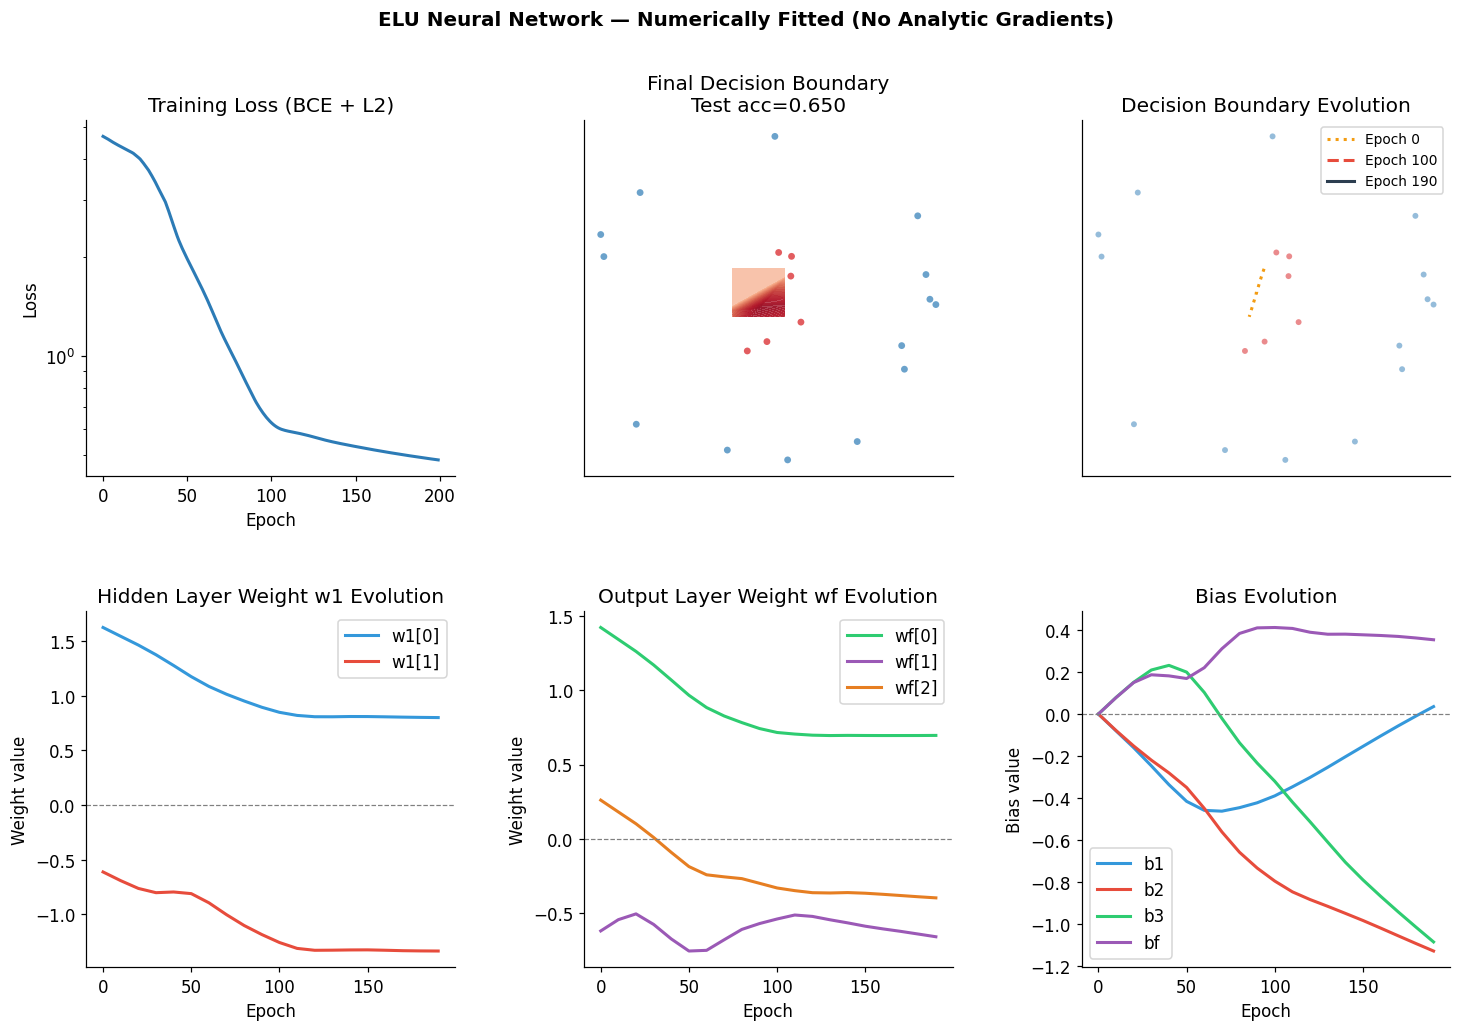

In [6]:
# ── Four-panel figure: loss, decision boundary, weight evolution ─────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# Panel 1: Loss curve
ax_loss = fig.add_subplot(gs[0, 0])
ax_loss.plot(nn_model.loss_history, color='#2c7bb6', lw=2)
ax_loss.set_title("Training Loss (BCE + L2)")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.set_yscale('log')

# Panel 2: Decision boundary (final)
ax_bound = fig.add_subplot(gs[0, 1])
xx_c, yy_c = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid_c = np.c_[xx_c.ravel(), yy_c.ravel()]
probs_c = nn_model.predict_proba(grid_c).reshape(xx_c.shape)
ax_bound.contourf(xx_c, yy_c, probs_c, levels=50, cmap='RdBu_r', alpha=0.8, vmin=0, vmax=1)
ax_bound.contour(xx_c, yy_c, probs_c, levels=[0.5], colors='white', lw=2)
ax_bound.scatter(X_cte[Y_cte==0,0], X_cte[Y_cte==0,1], c='#2c7bb6', s=20, alpha=0.7, edgecolors='none')
ax_bound.scatter(X_cte[Y_cte==1,0], X_cte[Y_cte==1,1], c='#d7191c', s=20, alpha=0.7, edgecolors='none')
ax_bound.set_title(f"Final Decision Boundary\nTest acc={nn_model.score(X_cte,Y_cte):.3f}")
ax_bound.set_xticks([]); ax_bound.set_yticks([])

# Panel 3: Decision boundary evolution (snapshots at 3 epochs)
ax_evo = fig.add_subplot(gs[0, 2])
snapshot_epochs = [0, len(nn_model.weight_snapshots)//2, len(nn_model.weight_snapshots)-1]
linestyles = [':', '--', '-']
contour_colors = ['#f39c12', '#e74c3c', '#2c3e50']
for ls, col, si in zip(linestyles, contour_colors, snapshot_epochs):
    _, p_snap = nn_model.weight_snapshots[si]
    _model_snap = LambdaClassifierModel(f=neural_network, p=p_snap)
    probs_snap = _model_snap.predict_proba(grid_c).reshape(xx_c.shape)
    ax_evo.contour(xx_c, yy_c, probs_snap, levels=[0.5],
                   colors=[col], linewidths=2, linestyles=[ls])
ax_evo.scatter(X_cte[Y_cte==0,0], X_cte[Y_cte==0,1], c='#2c7bb6', s=15, alpha=0.5, edgecolors='none')
ax_evo.scatter(X_cte[Y_cte==1,0], X_cte[Y_cte==1,1], c='#d7191c', s=15, alpha=0.5, edgecolors='none')
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0],color=c,ls=ls,lw=2,label=f"Epoch {nn_model.weight_snapshots[si][0]}")
              for ls,c,si in zip(linestyles,contour_colors,snapshot_epochs)]
ax_evo.legend(handles=legend_els, fontsize=9)
ax_evo.set_title("Decision Boundary Evolution"); ax_evo.set_xticks([]); ax_evo.set_yticks([])

# Panel 4 & 5: Weight evolution for w1 and wf across snapshots
ax_w1 = fig.add_subplot(gs[1, 0])
ax_wf = fig.add_subplot(gs[1, 1])

snap_epochs = [e for e,_ in nn_model.weight_snapshots]
w1_0 = np.array([p_snap['w1'][0] for _,p_snap in nn_model.weight_snapshots])
w1_1 = np.array([p_snap['w1'][1] for _,p_snap in nn_model.weight_snapshots])
wf_0 = np.array([p_snap['wf'][0] for _,p_snap in nn_model.weight_snapshots])
wf_1 = np.array([p_snap['wf'][1] for _,p_snap in nn_model.weight_snapshots])
wf_2 = np.array([p_snap['wf'][2] for _,p_snap in nn_model.weight_snapshots])

ax_w1.plot(snap_epochs, w1_0, label='w1[0]', lw=2, color='#3498db')
ax_w1.plot(snap_epochs, w1_1, label='w1[1]', lw=2, color='#e74c3c')
ax_w1.set_title("Hidden Layer Weight w1 Evolution")
ax_w1.set_xlabel("Epoch"); ax_w1.set_ylabel("Weight value")
ax_w1.legend(); ax_w1.axhline(0, color='gray', ls='--', lw=0.8)

ax_wf.plot(snap_epochs, wf_0, label='wf[0]', lw=2, color='#2ecc71')
ax_wf.plot(snap_epochs, wf_1, label='wf[1]', lw=2, color='#9b59b6')
ax_wf.plot(snap_epochs, wf_2, label='wf[2]', lw=2, color='#e67e22')
ax_wf.set_title("Output Layer Weight wf Evolution")
ax_wf.set_xlabel("Epoch"); ax_wf.set_ylabel("Weight value")
ax_wf.legend(); ax_wf.axhline(0, color='gray', ls='--', lw=0.8)

# Panel 6: Bias evolution
ax_b = fig.add_subplot(gs[1, 2])
for key, color in [('b1','#3498db'),('b2','#e74c3c'),('b3','#2ecc71'),('bf','#9b59b6')]:
    vals = [p_snap[key] for _,p_snap in nn_model.weight_snapshots]
    ax_b.plot(snap_epochs, vals, label=key, lw=2, color=color)
ax_b.set_title("Bias Evolution"); ax_b.set_xlabel("Epoch"); ax_b.set_ylabel("Bias value")
ax_b.legend(); ax_b.axhline(0, color='gray', ls='--', lw=0.8)

plt.suptitle("ELU Neural Network — Numerically Fitted (No Analytic Gradients)",
             fontsize=13, fontweight='bold')
plt.savefig('fig_neural_network.png', bbox_inches='tight')
plt.show()


## 4. Regression — Recovering True Parameters of a Sine Wave

We fit a learnable sine model `f(x) = a·sin(ω·x + φ) + c` starting from wrong parameters and watch the optimizer find the true values, even with outlier-corrupted data.


In [ ]:
# ── Data ────────────────────────────────────────────────────────────────────
np.random.seed(0)
n_pts = 400
X_sine = np.linspace(-3*np.pi, 3*np.pi, n_pts)[:, None]
Y_sine = np.sin(X_sine[:, 0]) + np.random.normal(0, 0.15, n_pts)
# 5% outliers
outlier_idx = np.random.choice(n_pts, 20, replace=False)
Y_sine[outlier_idx] += np.random.choice([-4, 4], 20)

split_s = int(0.8 * n_pts)
X_str, X_ste = X_sine[:split_s], X_sine[split_s:]
Y_str, Y_ste = Y_sine[:split_s], Y_sine[split_s:]

TRUE_PARAMS = {'a': 1.0, 'omega': 1.0, 'phi': 0.0, 'c': 0.0}

def sine_model_reg(x, p):
    """Learnable frequency, amplitude, phase, and offset."""
    return p['a'] * np.sin(p['omega'] * x[0] + p['phi']) + p['c']

p_sine_init = {'a': 2.5, 'omega': 0.4, 'phi': 1.8, 'c': -1.0}   # deliberately wrong

# Track parameter evolution during training
class TrackingRegressor(LambdaRegressorModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.param_history = defaultdict(list)
        self.epoch_history  = []

    def fit(self, X, Y, *, n_iter=100, lr=0.01, **kwargs):
        from lambdaml.lambda_utils import GradientComputer
        from lambdaml.lambda_model import Optimizer as Opt
        kwargs.pop('verbose', None)

        for epoch in range(n_iter):
            self.epoch_history.append(epoch)
            for k, v in self.p.items():
                self.param_history[k].append(v if np.isscalar(v) else float(v))

            gc = GradientComputer(method=self.diff_method, h=self.diff_h)
            grads = {key: gc.compute(self._objective, self.p, key, X, Y)
                     for key in self.p}
            Opt.step(self.optimizer_name, self.p, grads, self._opt_state, lr,
                     momentum=self.momentum, beta1=self.beta1, beta2=self.beta2,
                     epsilon=self.adam_eps)
            self.loss_history.append(self._objective(self.p, X, Y))
        return self

np.random.seed(5)
sine_tracker = TrackingRegressor(
    f=sine_model_reg,
    p=dict(p_sine_init),
    loss='pseudo_huber',
    diff_method=DiffMethod.COMPLEX_STEP,
    l2_factor=0.0005,
    optimizer=Optimizer.ADAM,
)
sine_tracker.fit(X_str, Y_str, n_iter=300, lr=0.03)
print("Learned params:")
for k in TRUE_PARAMS:
    print(f"  {k}: learned={sine_tracker.p[k]:.4f}  true={TRUE_PARAMS[k]:.4f}")
print(f"Test R²: {sine_tracker.score(X_ste, Y_ste):.4f}")


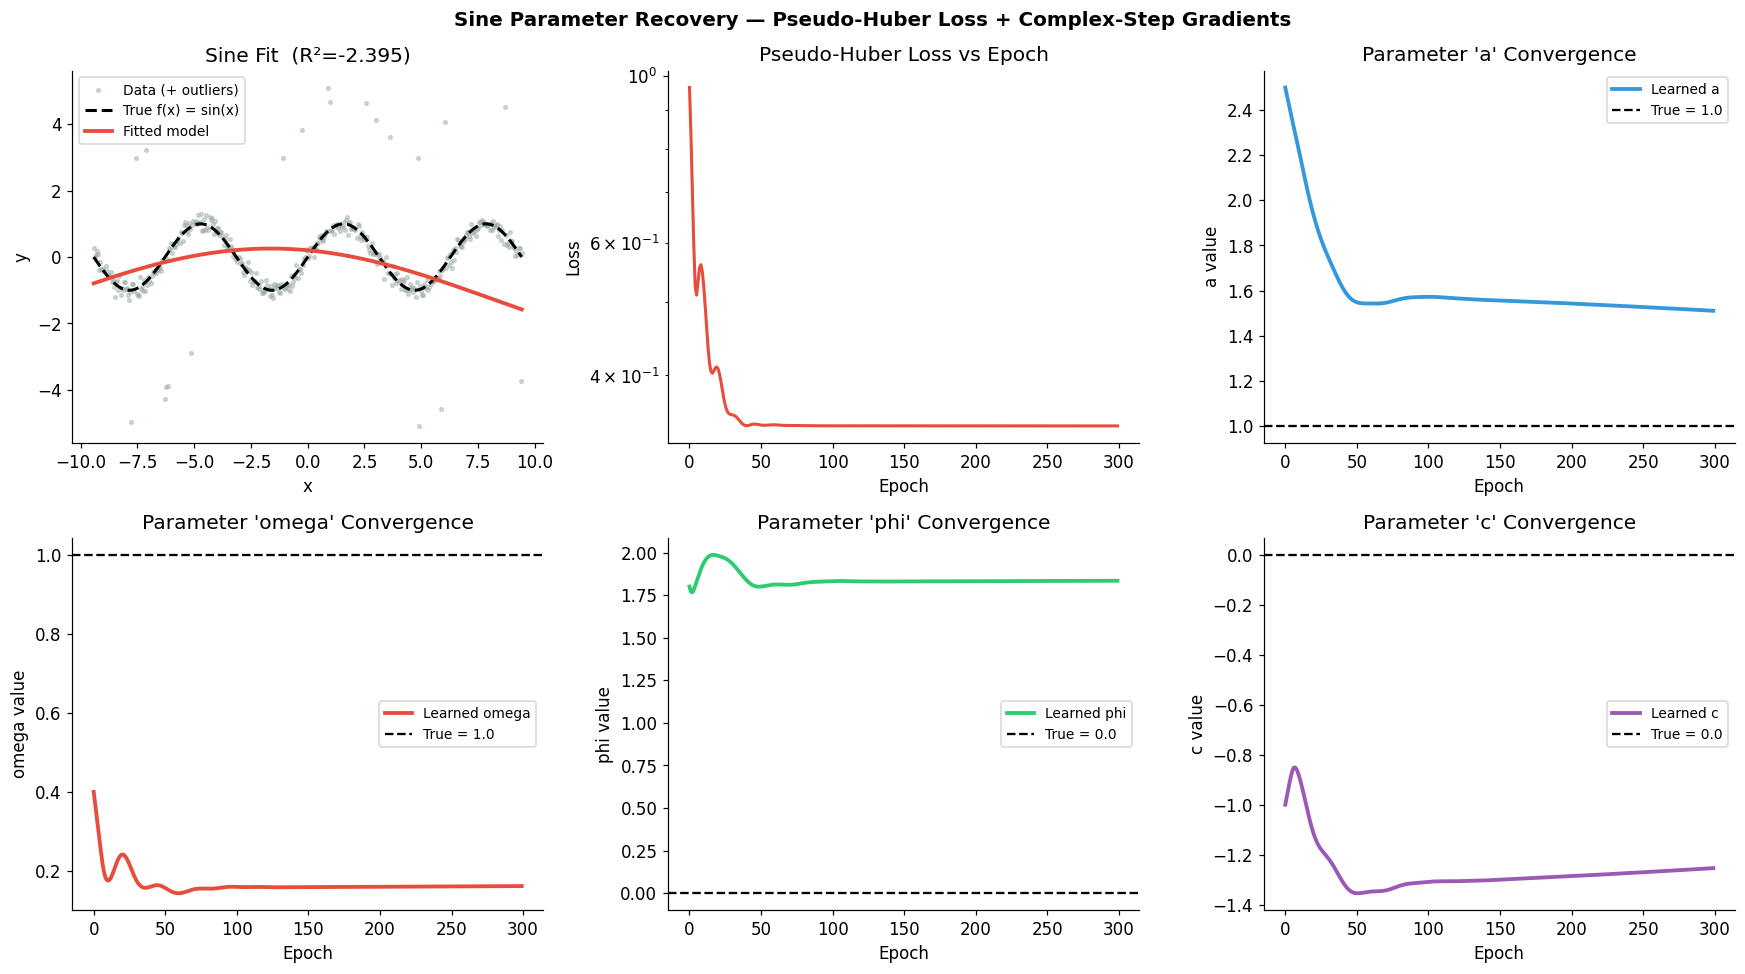

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

# Panel 1: Fit quality
ax = axes[0]
X_plot = np.linspace(-3*np.pi, 3*np.pi, 300)[:, None]
Y_pred = sine_tracker.predict(X_plot)
ax.scatter(X_sine[:, 0], Y_sine, s=6, alpha=0.4, color='#95a5a6', label='Data (+ outliers)')
ax.plot(X_plot[:, 0], np.sin(X_plot[:, 0]), 'k--', lw=2, label='True f(x) = sin(x)')
ax.plot(X_plot[:, 0], Y_pred, color='#e74c3c', lw=2.5, label='Fitted model')
ax.set_title(f"Sine Fit  (R²={sine_tracker.score(X_ste, Y_ste):.3f})")
ax.legend(fontsize=9); ax.set_xlabel("x"); ax.set_ylabel("y")

# Panel 2: Loss curve
ax = axes[1]
ax.plot(sine_tracker.loss_history, color='#e74c3c', lw=2)
ax.set_title("Pseudo-Huber Loss vs Epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_yscale('log')

# Panels 3–6: Parameter convergence
param_colors = {'a':'#3498db','omega':'#e74c3c','phi':'#2ecc71','c':'#9b59b6'}
for ax, (pname, pcolor) in zip(axes[2:], param_colors.items()):
    hist = sine_tracker.param_history[pname]
    true_val = TRUE_PARAMS[pname]
    ax.plot(sine_tracker.epoch_history, hist, color=pcolor, lw=2.5, label=f'Learned {pname}')
    ax.axhline(true_val, color='black', ls='--', lw=1.5, label=f'True = {true_val}')
    ax.set_title(f"Parameter '{pname}' Convergence")
    ax.set_xlabel("Epoch"); ax.set_ylabel(f"{pname} value")
    ax.legend(fontsize=9)

plt.suptitle("Sine Parameter Recovery — Pseudo-Huber Loss + Complex-Step Gradients",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_sine_regression.png', bbox_inches='tight')
plt.show()


## 5. Optimizer Comparison

How do SGD, Momentum, RMSProp, and Adam compare on the same task?


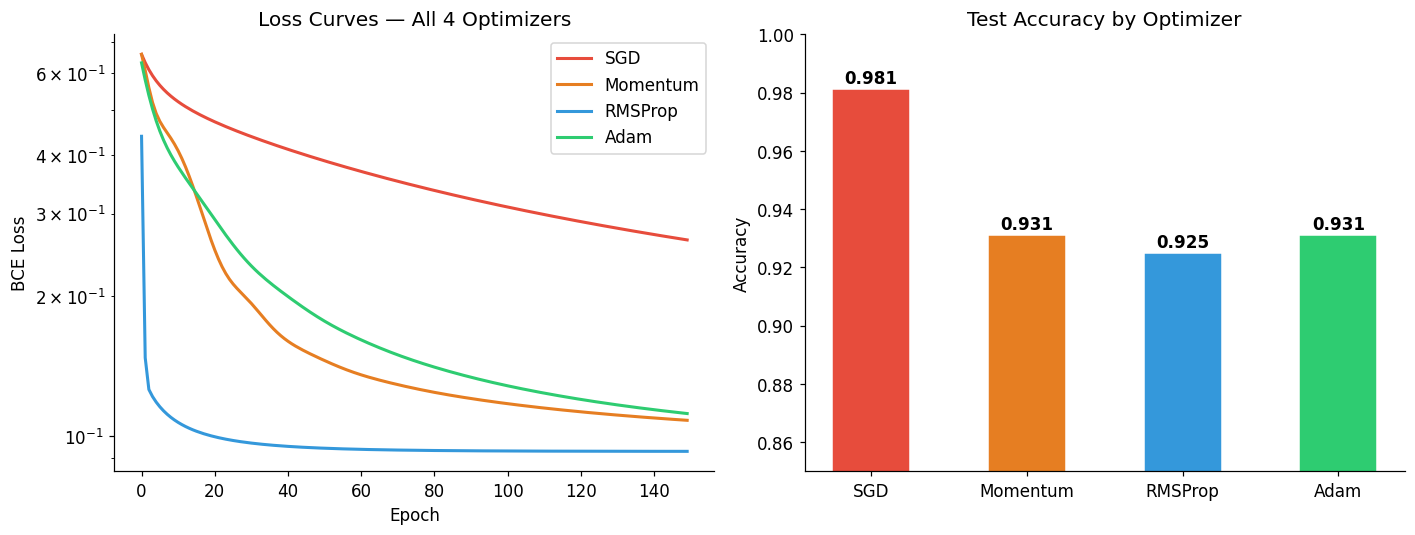

In [9]:
X_opt, Y_opt = make_blobs(n=400, seed=3)
split_o = int(0.8 * len(X_opt))
X_otr, X_ote = X_opt[:split_o], X_opt[split_o:]
Y_otr, Y_ote = Y_opt[:split_o], Y_opt[split_o:]

def logistic(x, p):
    return 1 / (1 + np.exp(-p['w'].dot(x) - p['b']))

optimizers = {
    'SGD':       Optimizer.SGD,
    'Momentum':  Optimizer.MOMENTUM,
    'RMSProp':   Optimizer.RMSPROP,
    'Adam':      Optimizer.ADAM,
}
opt_colors = {'SGD':'#e74c3c','Momentum':'#e67e22','RMSProp':'#3498db','Adam':'#2ecc71'}

opt_histories = {}
opt_accuracies = {}

for opt_name, opt in optimizers.items():
    np.random.seed(42)
    p0 = {'w': np.random.randn(2)*0.01, 'b': 0.0}
    model = LambdaClassifierModel(
        f=logistic, p=p0,
        diff_method=DiffMethod.CENTRAL,
        l2_factor=0.001,
        optimizer=opt,
    )
    model.fit(X_otr, Y_otr, n_iter=150, lr=0.05, verbose=False)
    opt_histories[opt_name] = model.loss_history
    opt_accuracies[opt_name] = model.score(X_ote, Y_ote)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for opt_name, history in opt_histories.items():
    ax.plot(history, lw=2, color=opt_colors[opt_name], label=opt_name)
ax.set_title("Loss Curves — All 4 Optimizers")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.set_yscale('log')

ax = axes[1]
names = list(opt_accuracies.keys())
accs  = list(opt_accuracies.values())
bars = ax.bar(names, accs, color=[opt_colors[n] for n in names], edgecolor='white', width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_title("Test Accuracy by Optimizer")
ax.set_ylabel("Accuracy")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{acc:.3f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_optimizers.png', bbox_inches='tight')
plt.show()


## 6. Derivative Method Benchmark

Accuracy vs wall-clock time for all 6 finite-difference methods on the same logistic regression task.


In [10]:
methods_bench = {
    'Forward':       DiffMethod.FORWARD,
    'Backward':      DiffMethod.BACKWARD,
    'Central':       DiffMethod.CENTRAL,
    'Five-Point':    DiffMethod.FIVE_POINT,
    'Complex-Step':  DiffMethod.COMPLEX_STEP,
    'Richardson':    DiffMethod.RICHARDSON,
}
method_colors = {
    'Forward':'#e74c3c','Backward':'#e67e22','Central':'#3498db',
    'Five-Point':'#2ecc71','Complex-Step':'#9b59b6','Richardson':'#1abc9c',
}

bench_results = {}
for m_name, method in methods_bench.items():
    np.random.seed(42)
    p0 = {'w': np.random.randn(2)*0.01, 'b': 0.0}
    model = LambdaClassifierModel(
        f=logistic, p=p0,
        diff_method=method,
        l2_factor=0.001,
        optimizer=Optimizer.ADAM,
    )
    t0 = time.perf_counter()
    model.fit(X_otr, Y_otr, n_iter=60, lr=0.05, verbose=False)
    elapsed = time.perf_counter() - t0
    bench_results[m_name] = {
        'time': elapsed,
        'acc': model.score(X_ote, Y_ote),
        'loss': model.compute_loss(X_ote, Y_ote),
        'history': model.loss_history,
    }

# ── Summary table ───────────────────────────────────────────────────────────
print(f"{'Method':<16} {'Test Acc':>10} {'Final Loss':>12} {'Time (s)':>10} {'Evals/param':>13}")
print("-" * 65)
evals_map = {'Forward':1,'Backward':1,'Central':2,'Five-Point':4,'Complex-Step':1,'Richardson':4}
for m_name, res in bench_results.items():
    print(f"{m_name:<16} {res['acc']:>10.4f} {res['loss']:>12.6f} {res['time']:>10.3f} {evals_map[m_name]:>13}")


Method             Test Acc   Final Loss   Time (s)   Evals/param
-----------------------------------------------------------------
Forward              0.9563     0.158327      0.461             1
Backward             0.9563     0.158327      0.466             1
Central              0.9563     0.158327      0.472             2
Five-Point           0.9563     0.158327      0.866             4
Complex-Step         0.9563     0.158327      0.350             1
Richardson           0.9563     0.158327      0.863             4


/tmp/ipykernel_9224/2055110833.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(m_names, rotation=30, ha='right', fontsize=9)


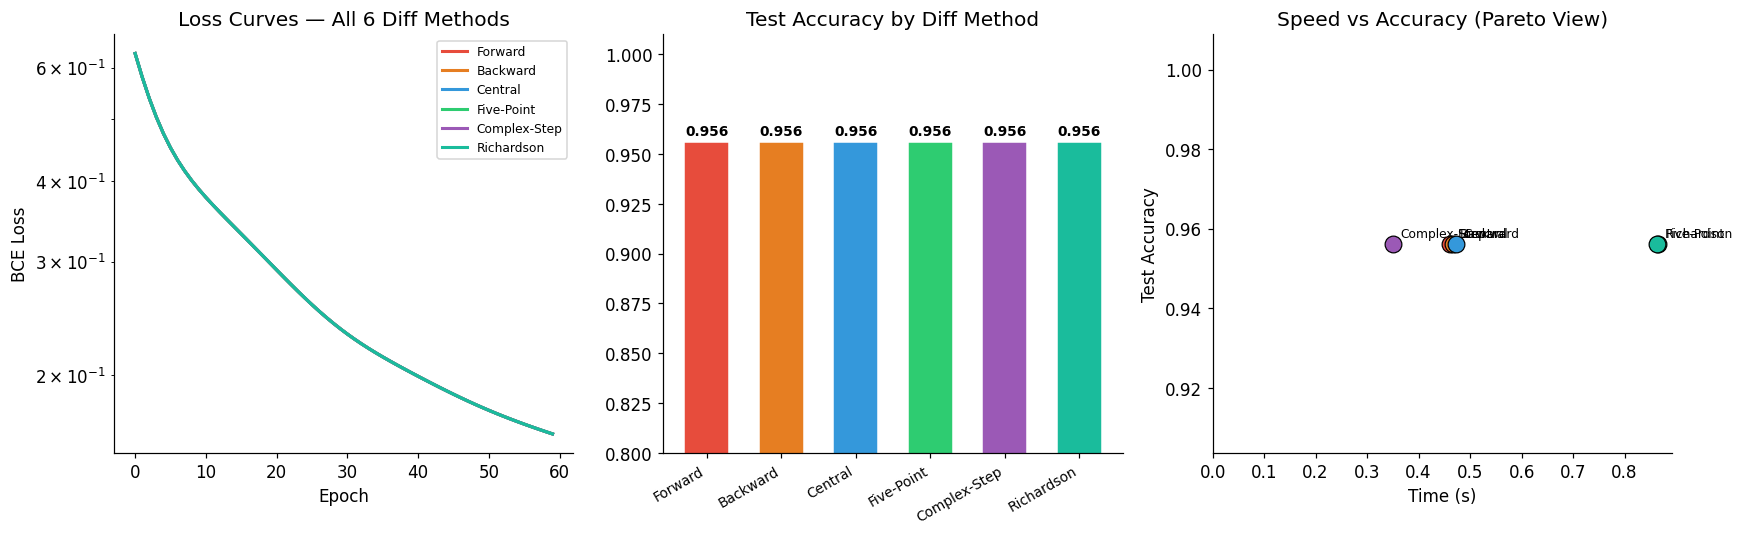


Takeaways:
  • Complex-step: fastest AND most accurate (when f supports complex inputs)
  • Forward/Backward: fastest for functions that can't accept complex inputs
  • Richardson / Five-Point: highest accuracy for real-valued expensive functions


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss curves
ax = axes[0]
for m_name, res in bench_results.items():
    ax.plot(res['history'], lw=2, color=method_colors[m_name], label=m_name)
ax.set_title("Loss Curves — All 6 Diff Methods"); ax.set_yscale('log')
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss"); ax.legend(fontsize=8)

# Accuracy bar
ax = axes[1]
m_names = list(bench_results.keys())
accs = [bench_results[m]['acc'] for m in m_names]
bars = ax.bar(m_names, accs, color=[method_colors[m] for m in m_names],
              edgecolor='white', width=0.6)
ax.set_ylim(0.8, 1.01); ax.set_title("Test Accuracy by Diff Method")
ax.set_xticklabels(m_names, rotation=30, ha='right', fontsize=9)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.003,
            f"{acc:.3f}", ha='center', fontsize=9, fontweight='bold')

# Speed vs accuracy scatter (Pareto frontier)
ax = axes[2]
for m_name, res in bench_results.items():
    ax.scatter(res['time'], res['acc'],
               color=method_colors[m_name], s=120, zorder=5,
               edgecolors='black', linewidths=0.8)
    ax.annotate(m_name, (res['time'], res['acc']),
                textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_title("Speed vs Accuracy (Pareto View)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Test Accuracy")
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('fig_diff_benchmark.png', bbox_inches='tight')
plt.show()

print("\nTakeaways:")
print("  • Complex-step: fastest AND most accurate (when f supports complex inputs)")
print("  • Forward/Backward: fastest for functions that can't accept complex inputs")
print("  • Richardson / Five-Point: highest accuracy for real-valued expensive functions")


## 7. Regularization — L1 vs L2 vs None

With the corrected L1 formula (`|θ|` not `θ`), we can now see true sparsity-inducing behaviour.


/tmp/ipykernel_9224/1847634276.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(reg_names, rotation=15, ha='right', fontsize=9)


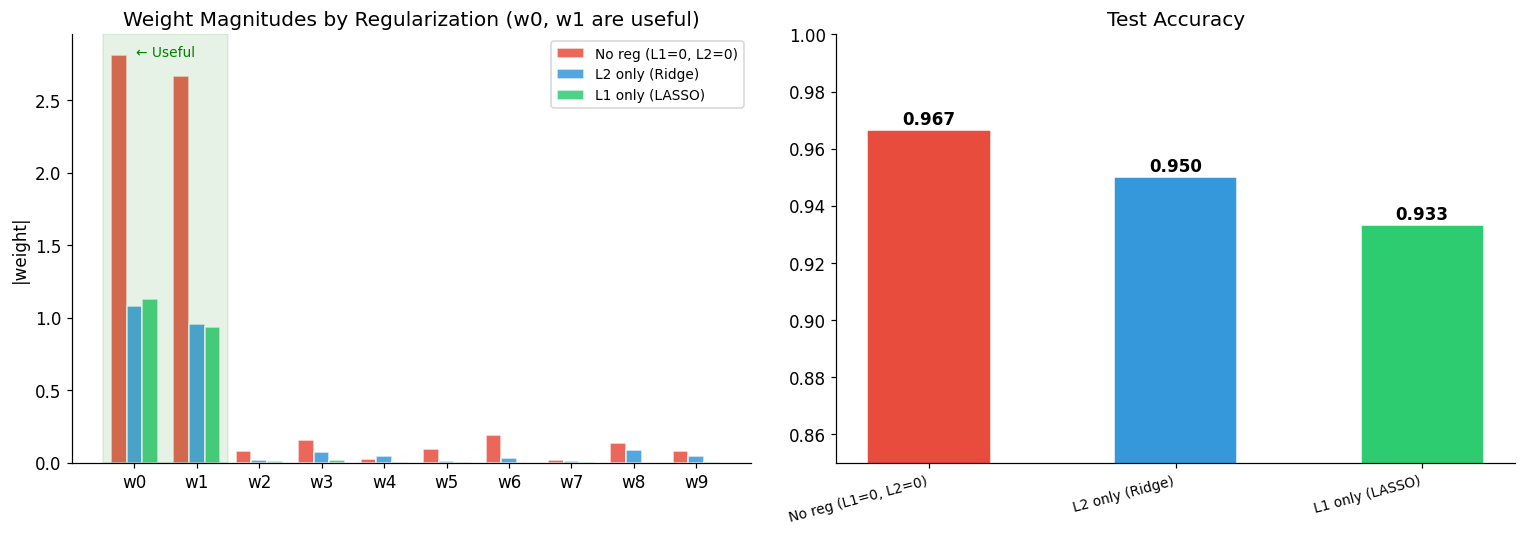

L1 (LASSO) shrinks irrelevant weights toward zero — true sparsity induction.
L2 (Ridge) keeps all weights but small — no sparsity, just bounded norms.


In [12]:
# ── High-dimensional sparse problem ─────────────────────────────────────────
np.random.seed(0)
n_features = 10
n_samples  = 300
# Only features 0 and 1 are actually useful
X_hi = np.random.randn(n_samples, n_features)
Y_hi = (X_hi[:, 0] - X_hi[:, 1] > 0).astype(float)

split_h = int(0.8 * n_samples)
X_htr, X_hte = X_hi[:split_h], X_hi[split_h:]
Y_htr, Y_hte = Y_hi[:split_h], Y_hi[split_h:]

def logistic_hi(x, p):
    return 1 / (1 + np.exp(-p['w'].dot(x) - p['b']))

reg_settings = {
    'No reg (L1=0, L2=0)': dict(l1_factor=0.0, l2_factor=0.0),
    'L2 only (Ridge)':     dict(l1_factor=0.0, l2_factor=0.05),
    'L1 only (LASSO)':     dict(l1_factor=0.1, l2_factor=0.0),
}
reg_colors = {'No reg (L1=0, L2=0)':'#e74c3c', 'L2 only (Ridge)':'#3498db', 'L1 only (LASSO)':'#2ecc71'}

reg_weights = {}
reg_accs    = {}

for reg_name, reg_kw in reg_settings.items():
    np.random.seed(42)
    p0 = {'w': np.zeros(n_features), 'b': 0.0}
    model = LambdaClassifierModel(
        f=logistic_hi, p=p0,
        diff_method=DiffMethod.COMPLEX_STEP,
        optimizer=Optimizer.ADAM,
        **reg_kw,
    )
    model.fit(X_htr, Y_htr, n_iter=100, lr=0.05, verbose=False)
    reg_weights[reg_name] = model.p['w'].copy()
    reg_accs[reg_name]    = model.score(X_hte, Y_hte)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(n_features)
width = 0.25
offsets = [-width, 0, width]
for (reg_name, weights), offset in zip(reg_weights.items(), offsets):
    ax.bar(x_pos + offset, np.abs(weights), width, label=reg_name,
           color=reg_colors[reg_name], alpha=0.85, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'w{i}' for i in range(n_features)])
ax.set_title("Weight Magnitudes by Regularization (w0, w1 are useful)")
ax.set_ylabel("|weight|"); ax.legend(fontsize=9)
ax.axvspan(-0.5, 1.5, alpha=0.1, color='green', label='Useful features')
ax.text(0.5, ax.get_ylim()[1]*0.95, '← Useful', ha='center', fontsize=9, color='green')

ax = axes[1]
reg_names = list(reg_accs.keys())
accs_r = list(reg_accs.values())
bars = ax.bar(reg_names, accs_r,
              color=[reg_colors[n] for n in reg_names], edgecolor='white', width=0.5)
ax.set_ylim(0.85, 1.0); ax.set_title("Test Accuracy")
ax.set_xticklabels(reg_names, rotation=15, ha='right', fontsize=9)
for bar, acc in zip(bars, accs_r):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{acc:.3f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_regularization.png', bbox_inches='tight')
plt.show()

print("L1 (LASSO) shrinks irrelevant weights toward zero — true sparsity induction.")
print("L2 (Ridge) keeps all weights but small — no sparsity, just bounded norms.")


## 8. Learning Rate Schedules

Visualising how each schedule shapes the learning rate, and its effect on convergence.


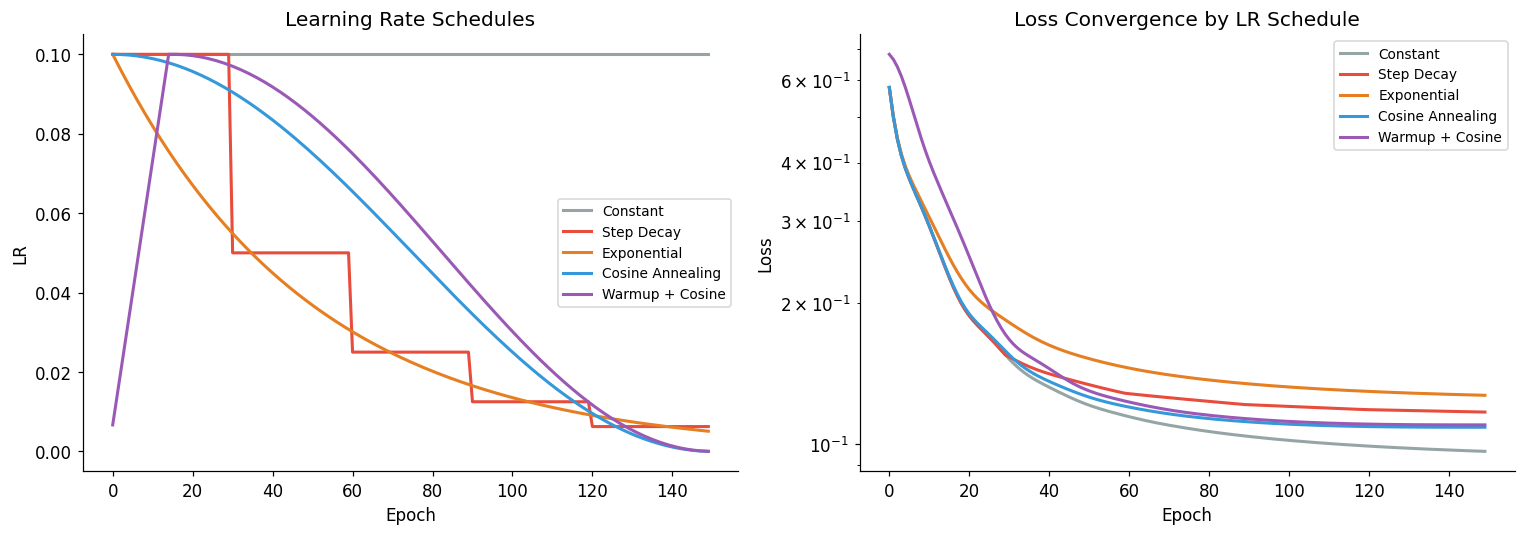

In [13]:
T_MAX = 150
lr0   = 0.1
t_arr = np.arange(T_MAX)

schedules = {
    'Constant':          LRSchedule.constant(lr0),
    'Step Decay':        LRSchedule.step_decay(drop=0.5, epochs_drop=30),
    'Exponential':       LRSchedule.exponential_decay(k=0.02),
    'Cosine Annealing':  LRSchedule.cosine_annealing(T_max=T_MAX),
    'Warmup + Cosine':   LRSchedule.warmup_cosine(warmup=15, T_max=T_MAX),
}
sched_colors = {
    'Constant':'#95a5a6','Step Decay':'#e74c3c','Exponential':'#e67e22',
    'Cosine Annealing':'#3498db','Warmup + Cosine':'#9b59b6',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for sname, sched in schedules.items():
    lr_vals = [sched(lr0, t) for t in t_arr]
    ax.plot(t_arr, lr_vals, lw=2, color=sched_colors[sname], label=sname)
ax.set_title("Learning Rate Schedules"); ax.set_xlabel("Epoch"); ax.set_ylabel("LR")
ax.legend(fontsize=9)

# Fit with each schedule and compare convergence
ax = axes[1]
for sname, sched in schedules.items():
    np.random.seed(42)
    p0 = {'w': np.random.randn(2)*0.01, 'b': 0.0}
    model = LambdaClassifierModel(
        f=logistic, p=p0,
        diff_method=DiffMethod.CENTRAL,
        l2_factor=0.001,
        optimizer=Optimizer.ADAM,
        lr_schedule=sched,
    )
    model.fit(X_otr, Y_otr, n_iter=T_MAX, lr=lr0, verbose=False)
    ax.plot(model.loss_history, lw=2, color=sched_colors[sname], label=sname)

ax.set_title("Loss Convergence by LR Schedule"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=9); ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig_lr_schedules.png', bbox_inches='tight')
plt.show()


## 9. Gradient Accuracy Verification

A sanity check: for a function with a known analytic gradient, how close does each method get?


Method              max |err|  per-component errors
---------------------------------------------------------------------------
Forward              5.27e-08  [4.78e-08  5.27e-08  3.24e-08  1.01e-08  1.48e-08]
Backward             4.95e-08  [1.18e-08  6.92e-09  2.72e-08  4.95e-08  1.48e-08]
Central              4.63e-11  [4.63e-11  4.53e-11  2.38e-11  8.17e-12  1.11e-12]
Five-Point           4.38e-13  [4.38e-13  6.88e-15  2.10e-13  1.59e-13  2.84e-14]
Complex-Step         2.22e-16  [0.00e+00  1.11e-16  0.00e+00  0.00e+00  2.22e-16]
Richardson           1.22e-10  [4.63e-11  5.25e-11  1.22e-10  8.17e-12  9.89e-11]


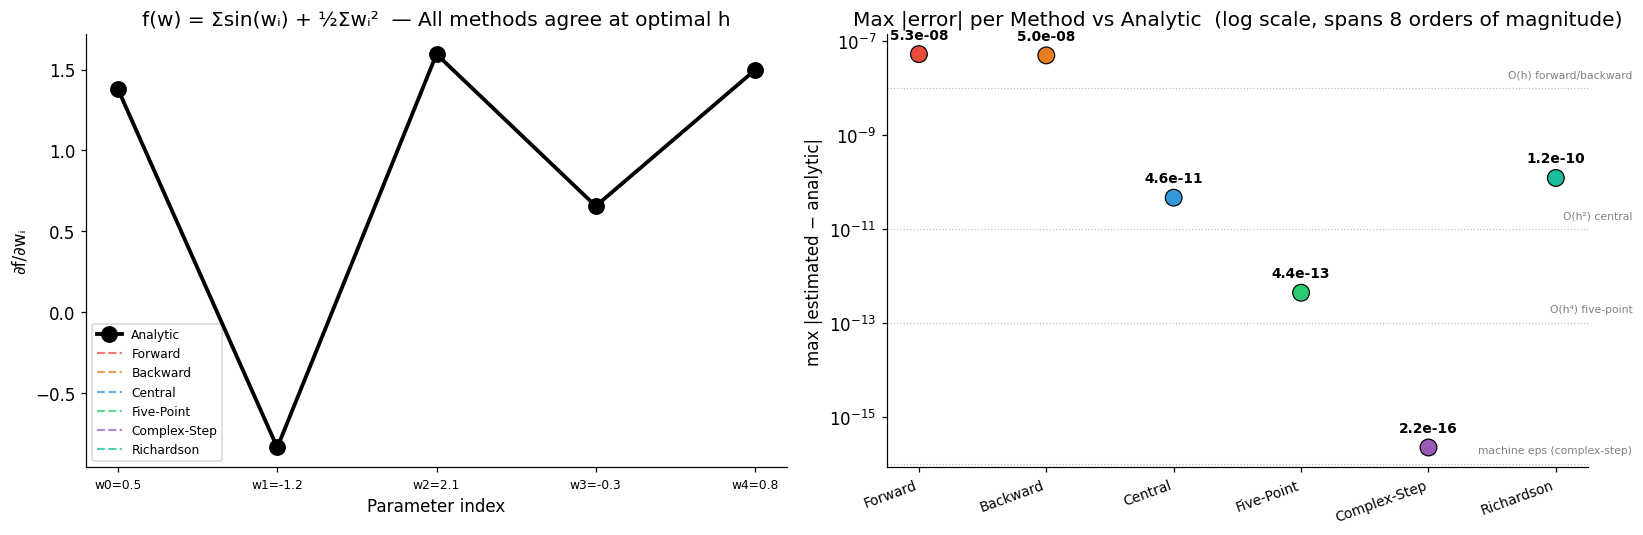

In [14]:
# f(w) = sum(sin(w_i)) + 0.5 * sum(w_i^2)
# f'(w_i) = cos(w_i) + w_i  (analytic)

def f_vec(w):
    return np.sum(np.sin(w)) + 0.5 * np.sum(w**2)

def analytic_grad_fn(w):
    return np.cos(w) + w  # exact: d/dw[sin(w) + 0.5w^2] = cos(w) + w

# Use a challenging test point where values span a range
test_w_acc = np.array([0.5, -1.2, 2.1, -0.3, 0.8])
analytic_acc = analytic_grad_fn(test_w_acc)

# Compute all estimates and errors using factory to avoid closure-in-loop
def make_obj():
    def obj_w(p, _X, _Y):
        return f_vec(p['w'])
    return obj_w

errors_acc = {}
grad_estimates = {}
for m_name, method in methods_bench.items():
    gc = GradientComputer(method=method)
    grad_est = gc.compute(make_obj(), {'w': test_w_acc.copy()}, 'w', None, None)
    grad_estimates[m_name] = grad_est
    errors_acc[m_name] = np.abs(grad_est - analytic_acc)

# Print error table
print(f"{'Method':<16} {'max |err|':>12}  {'per-component errors'}")
print("-" * 75)
for m_name, errs in errors_acc.items():
    vals = '  '.join(f'{e:.2e}' for e in errs)
    print(f"{m_name:<16} {errs.max():>12.2e}  [{vals}]")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: gradient values — show all agree (differences sub-pixel at this scale is expected)
ax = axes[0]
x_idx = np.arange(len(test_w_acc))
ax.plot(x_idx, analytic_acc, 'ko-', lw=2.5, ms=10, label='Analytic', zorder=10)
for m_name, grad_est in grad_estimates.items():
    ax.plot(x_idx, grad_est, '--', lw=1.4, alpha=0.75,
            color=list(method_colors.values())[list(methods_bench.keys()).index(m_name)],
            label=m_name)
ax.set_title("f(w) = Σsin(wᵢ) + ½Σwᵢ²  — All methods agree at optimal h")
ax.set_xlabel("Parameter index"); ax.set_ylabel("∂f/∂wᵢ")
ax.legend(fontsize=8); ax.set_xticks(x_idx)
ax.set_xticklabels([f'w{i}={v:.1f}' for i,v in enumerate(test_w_acc)], fontsize=8)

# Right: max absolute error per method — scatter plot on log scale
ax = axes[1]
m_names_list = list(errors_acc.keys())
max_errs = [errors_acc[m].max() for m in m_names_list]
colors_list = list(method_colors.values())
ax.scatter(range(len(m_names_list)), max_errs, s=120, zorder=5,
           c=colors_list, edgecolors='black', linewidths=0.8)
for i, (name, err) in enumerate(zip(m_names_list, max_errs)):
    ax.annotate(f'{err:.1e}', (i, err), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
ax.set_yscale('log')
ax.set_xticks(range(len(m_names_list)))
ax.set_xticklabels(m_names_list, rotation=20, ha='right', fontsize=9)
ax.set_title("Max |error| per Method vs Analytic  (log scale, spans 8 orders of magnitude)")
ax.set_ylabel("max |estimated − analytic|")
# Annotate order lines
for exp, label in [(-8,'O(h) forward/backward'), (-11,'O(h²) central'), (-13,'O(h⁴) five-point'), (-16,'machine eps (complex-step)')]:
    ax.axhline(10**exp, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax.text(5.6, 10**exp * 1.5, label, fontsize=7, color='gray', va='bottom', ha='right')

plt.tight_layout()
plt.savefig('fig_gradient_accuracy.png', bbox_inches='tight')
plt.show()


## 10. Progress Bars, Vectorized Mode & `eval_every`  *(new in v1.0.3)*

Three additions that improve the training experience and significantly reduce wall-clock time.

### `progress_bar=True` (default on `fit`, opt-in on `predict`)
`fit()` shows a live tqdm bar over epochs with current loss and learning rate in the postfix.
`predict()` / `predict_proba()` accept `progress_bar=True` for a per-sample bar — useful when
running inference on a large dataset.

### `eval_every=N`
By default the model re-evaluates the full objective every epoch just to log the loss — an extra
full forward pass that can double training time on large datasets. Setting `eval_every=10` or
higher skips that re-evaluation on in-between epochs with no effect on the gradient updates.

### `vectorized=True`
By default `_predict_batch` loops over samples in Python: `[f(x, p) for x in X]`. If you write
your `f` to accept the full `X` matrix at once (which any pure-numpy function already does),
setting `vectorized=True` eliminates that loop and can yield 2–10× speedup depending on model size.


In [ ]:
# ── Demo dataset ─────────────────────────────────────────────────────────────
np.random.seed(0)
n = 200
X_spd = np.random.randn(n, 3)
Y_spd = X_spd @ np.array([1.5, -0.8, 0.3]) + 0.1 * np.random.randn(n)

# ── 1. progress_bar on fit ────────────────────────────────────────────────────
print("── progress_bar=True (default) ──")

def linear3(x, p):
    return p['w'].dot(x) + p['b']

m_pb = LambdaRegressorModel(f=linear3, p={'w': np.zeros(3), 'b': 0.0})
m_pb.fit(X_spd, Y_spd, n_iter=40, lr=0.05, progress_bar=True)
print(f"  Final loss: {m_pb.loss_history[-1]:.4f}  |  history length: {len(m_pb.loss_history)}")

# ── 2. eval_every — skip loss logging on most epochs ─────────────────────────
print("\n── eval_every=10 (logs every 10th epoch only) ──")

m_ee = LambdaRegressorModel(f=linear3, p={'w': np.zeros(3), 'b': 0.0})
t0 = time.perf_counter()
m_ee.fit(X_spd, Y_spd, n_iter=40, lr=0.05, progress_bar=True, eval_every=10)
t_ee = time.perf_counter() - t0
print(f"  history length: {len(m_ee.loss_history)}  |  time: {t_ee:.3f}s")

m_base = LambdaRegressorModel(f=linear3, p={'w': np.zeros(3), 'b': 0.0})
t0 = time.perf_counter()
m_base.fit(X_spd, Y_spd, n_iter=40, lr=0.05, progress_bar=False, eval_every=1)
t_base = time.perf_counter() - t0
print(f"  eval_every=1 time: {t_base:.3f}s  →  eval_every=10 is ~{t_base/t_ee:.1f}× faster")

# ── 3. vectorized=True ────────────────────────────────────────────────────────
print("\n── vectorized=True ──")

def linear3_vec(X, p):
    """f now receives the full (n_samples, n_features) matrix at once."""
    return X @ p['w'] + p['b']

m_vec = LambdaRegressorModel(f=linear3_vec, p={'w': np.zeros(3), 'b': 0.0}, vectorized=True)
t0 = time.perf_counter()
m_vec.fit(X_spd, Y_spd, n_iter=40, lr=0.05, progress_bar=True)
t_vec = time.perf_counter() - t0

m_loop = LambdaRegressorModel(f=linear3, p={'w': np.zeros(3), 'b': 0.0}, vectorized=False)
t0 = time.perf_counter()
m_loop.fit(X_spd, Y_spd, n_iter=40, lr=0.05, progress_bar=False)
t_loop = time.perf_counter() - t0

print(f"  loop  time: {t_loop:.3f}s")
print(f"  vec   time: {t_vec:.3f}s  →  {t_loop/t_vec:.1f}× faster")

# ── 4. progress_bar on predict ────────────────────────────────────────────────
print("\n── progress_bar=True on predict ──")
preds = m_pb.predict(X_spd[:10], progress_bar=True)
print(f"  Predictions (first 5): {preds[:5].round(2)}")

# ── 5. Speed comparison bar chart ────────────────────────────────────────────
labels  = ['Default\n(eval_every=1)', 'eval_every=10', 'vectorized=True']
timings = [t_base, t_ee, t_vec]
colors  = ['#4c72b0', '#55a868', '#c44e52']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, timings, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Training time — 40 epochs, 200 samples, 3 params\n(lower is better)')
for bar, t in zip(bars, timings):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{t:.3f}s', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(timings) * 1.25)
plt.tight_layout()
plt.show()


## 11. Summary

| Feature | v1.0.3 | v1.0.2 | Original |
|---|---|---|---|
| Derivative methods | 6 (Forward, Backward, Central, 5-Point, Complex-Step, Richardson) | 6 | 1 (Central only) |
| Epsilon used | Float64-optimal per method | Float64-optimal | `float16.eps` ≈ 0.001 (bug!) |
| L1 regularization | `Σ\|θ\|` (correct) | `Σ\|θ\|` | `Σθ` (raw values — bug!) |
| L2 regularization | ✓ | ✓ | ✓ |
| Optimizers | SGD, Momentum, RMSProp, Adam | SGD, Momentum, RMSProp, Adam | SGD only |
| Mini-batch SGD | ✓ | ✓ | ✗ |
| Early stopping | ✓ | ✓ | ✗ |
| LR schedules | 5 (constant, step, exp, cosine, warmup+cosine) | 5 | None |
| Model types | Classifier + Regressor | Classifier + Regressor | Classifier only |
| Regression losses | MSE, MAE, Huber, Pseudo-Huber | MSE, MAE, Huber, Pseudo-Huber | None |
| Progress bars (`tqdm`) | ✓ fit + predict | ✗ | ✗ |
| `eval_every` | ✓ (skip loss evals for speed) | ✗ | ✗ |
| Vectorized mode | ✓ (`vectorized=True`) | ✗ | ✗ |
| Backward compat | ✓ (`predict_probability`, `compute_log_likelihood`) | ✓ | — |
| Complex-step safe | ✓ | ✓ | — |

### The core insight
**LambdaML decouples the model definition from gradient computation.** You write `f(x, p)` — any numpy-callable, however exotic — and the library handles the rest. The "lambda" really can be any function: logistic regression, a neural network with custom activations, a physics equation, a learnable signal transform, or something entirely new.

### Speed cheat-sheet (v1.0.3)
- **`eval_every=10`** — biggest easy win; cuts loss-logging overhead by 10×
- **`vectorized=True`** — write `f(X, p)` to accept the full matrix; eliminates the Python sample loop (2–10× speedup)
- **`batch_size=N`** — reduce samples per gradient step for stochastic training
- **`DiffMethod.FORWARD`** — 1 f-eval per param instead of 2 (noisier but cheaper)

### When to use for Kaggling
- Fitting **domain equations** with unknown parameters (physics-based pricing, pharmacokinetics, decay curves)
- **Directly optimising non-differentiable competition metrics** — set your NDCG/F-beta/Cohen's-kappa as the loss
- **Exotic meta-learner** in stacking ensembles
- **Small-data + custom hypothesis** scenarios where sklearn doesn't have your model form
